Preparação para a Análise do Fluxo de Potência

In [1]:
import pandas as pd
import py_dss_interface
from py_dss_toolkit import dss_tools

dss_file = r"C:\Dados_teste\OpenDSS\GWO\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"

dss = py_dss_interface.DSS()

dss_tools.update_dss(dss)

dss.text(f"compile [{dss_file}]")

def decide_element(bus: str, buses_df: pd.DataFrame, trafo_df: pd.DataFrame, lines_df: pd.DataFrame):
    bus = bus.split(".")[0]
    elements_query = buses_df.query(f"name == '{bus}'")["all_pde_active_bus"].iloc[0]

    distance = 1e6
    for element in elements_query:
        element_type, element_name = element.split(".")

        if element_type == "Line":
            segment_df = lines_df.query(f"name == '{element_name}'")

            element_bus = segment_df["bus_name"].iloc[0]
            distance_bus = buses_df.query(f"name == '{element_bus}'")["distance"].iloc[0]

            if "mt" in element_name:
                kv = 13.8

            elif "bt" in element_name:
                kv = 0.38

            else:
                continue

        elif element_type == "Transformer":
            element_bus = trafo_df.query(f"name == '{element_name}'")["bus_name"].iloc[0]
            distance_bus = buses_df.query(f"name == '{element_bus}'")["distance"].iloc[0]
            kv = trafo_df.query(f"name == '{element_name}'")["kv"].iloc[0]

        else:
            continue

        if distance_bus < distance:
            distance = distance_bus
            selected_element = element_name
            selected_element_type = element_type
            selected_kv = kv

    return selected_element_type, selected_element, selected_kv

def calc_rpf() -> float:
    soma = 0
    for name in dss.monitors.names:
        if "voltage" in name:
            continue

        dss.monitors.name = name
        monitor = dss.monitors.channel(1)

        soma += sum(x for x in monitor if x < 0)

    return soma

buses_df = dss_tools.model.buses_df
trafo_df = dss_tools.model.transformers_df
lines_df = dss_tools.model.lines_df

trafo_df["bus_name"] = trafo_df["bus"].str.split(".").str[0]
lines_df["bus_name"] = lines_df["bus1"].str.split(".").str[0]

buses_df = buses_df[["name", "distance", "all_pce_active_bus", "all_pde_active_bus"]]


Análise do Fluxo de Potência

Caso Base


,kwh,kvarh,zone losses kwh
0,49444.317416,65469.605055,5882.456263


Caso Ótimo


,kwh,kvarh,zone losses kwh
0,49869.569337,63380.09986,5123.188231


,Caso,Fluxo Reverso Total (kWh)
0,Caso Base,-23302.206599
1,Caso Ótimo,-19495.259545


Gráficos


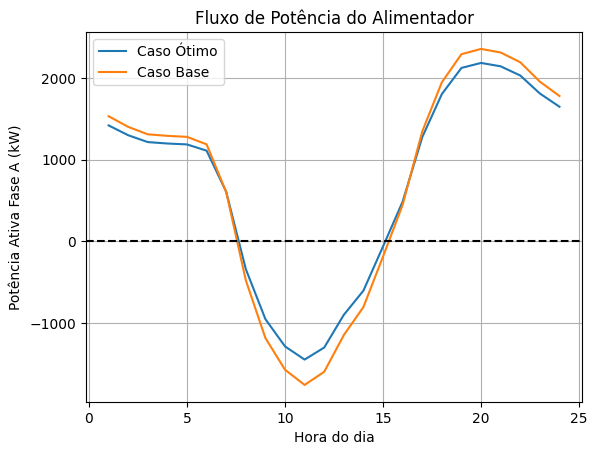

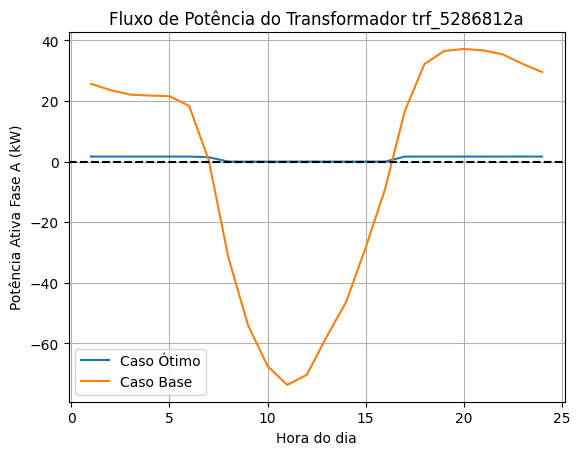

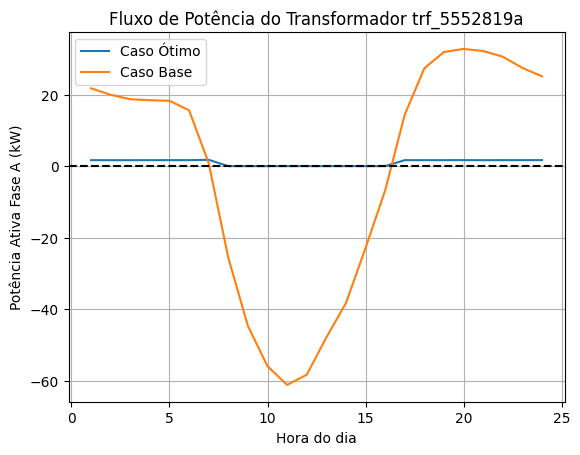

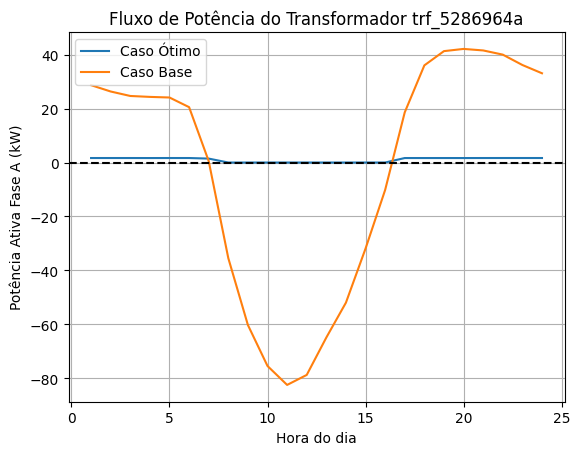

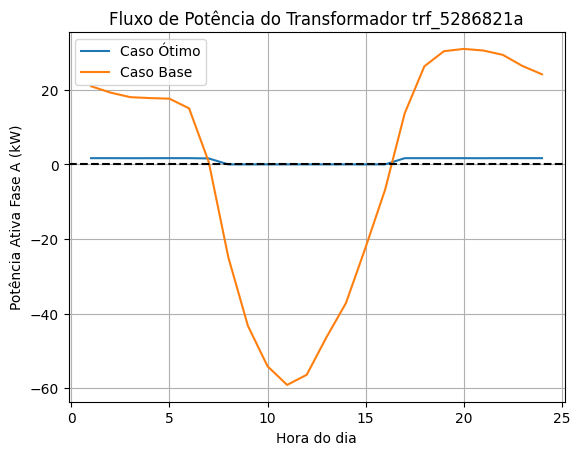

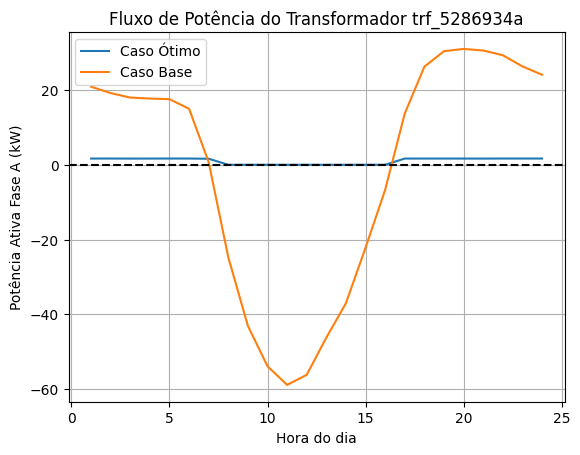

In [2]:
import py_dss_interface
from py_dss_toolkit import dss_tools
from matplotlib import pyplot as plt

cases = ["Caso Base", "Caso Ótimo"]
#solution_buses = ['82036275286964.1.2.3.4', '82026915286812.1.2.3.4', '82032765552819.1.2.3.4'] #Colocar a solução aqui
solution_buses = ['82036275286964.1.2.3.4', '82026915286812.1.2.3.4', '82032765552819.1.2.3.4', '82025745286821.1.2.3.4', '82049885286934.1.2.3.4']
#solution_buses = ['82041765002086', '94511165002086b', '84117165002086', '84117145002086', '82027905286808']

dss_file = r"C:\Dados_teste\OpenDSS\GWO\Alim_Meia_Ponte_5_REDUZIDO\Master_PyDSS_Interface.dss"

dss = py_dss_interface.DSS()

dss_tools.update_dss(dss)

df_rpf = pd.DataFrame(columns=["Caso", "Fluxo Reverso Total (kWh)"])

for case in cases:

    dss.text(f"compile [{dss_file}]")

    dss.text("Redirect 'PV_System_120_MeiaPonte.dss'")

    if case == "Caso Ótimo":

        for i, bus in enumerate(solution_buses):
            element_type, element_name, kv = decide_element(bus, buses_df, trafo_df, lines_df)
            pot = 280

            dss.text(f"New Storage.Battery_{i} phases=3 bus1={bus} kv={kv} kWrated={pot} kWhrated={8*pot} dispmode=follow %stored=50")
            
            dss.text(f"New StorageController.SC_{i} element={element_type}.{element_name} terminal=1 modedis=peakShave elementList=[Battery_{i}]\n"
            f"~ MonPhase=AVG kwtarget=5 modecharge=peakShaveLow kwtargetLow=0\n\n")

    dss.text(f"buscoords BusCoords.csv")

    dss.text("set mode=daily")
    dss.text("set stepsize=1h")
    dss.text("set number=24")

    dss.solution.solve()

    energymeter_df = dss_tools.results.energymeters

    elem_1, elem_2, elem_3, elem_4, elem_5 = "trf_5286812a", "trf_5552819a", "trf_5286964a", "trf_5286821a", "trf_5286934a"

    if case == "Caso Ótimo":
        df_optimal_feeder = dss_tools.results.monitor("feeder")
        df_optimal_trafo_1 = dss_tools.results.monitor(elem_1)
        df_optimal_trafo_2 = dss_tools.results.monitor(elem_2)
        df_optimal_trafo_3 = dss_tools.results.monitor(elem_3)
        df_optimal_trafo_4 = dss_tools.results.monitor(elem_4)
        df_optimal_trafo_5 = dss_tools.results.monitor(elem_5)

    elif case == "Caso Base":
        df_base_feeder = dss_tools.results.monitor("feeder")
        df_base_trafo_1 = dss_tools.results.monitor(elem_1)
        df_base_trafo_2 = dss_tools.results.monitor(elem_2)
        df_base_trafo_3  = dss_tools.results.monitor(elem_3)
        df_base_trafo_4  = dss_tools.results.monitor(elem_4)
        df_base_trafo_5  = dss_tools.results.monitor(elem_5)

    print(f"{case}")
    display(energymeter_df[["kwh", "kvarh", "zone losses kwh"]])

    rpf = calc_rpf()
    df2 = pd.DataFrame({"Caso": [case], "Fluxo Reverso Total (kWh)": [rpf]})

    df_rpf = pd.concat([df_rpf, df2], ignore_index=True)

#Fluxo reverso total
display(df_rpf)

#### Gráfico
print("Gráficos")

# Alimentador
plt.plot(df_optimal_feeder["Hour"], df_optimal_feeder[" P1 (kW)"], label="Caso Ótimo")
plt.plot(df_optimal_feeder["Hour"], df_base_feeder[" P1 (kW)"], label="Caso Base")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa Fase A (kW)")
plt.legend()
plt.grid(True)
plt.axhline(y=0, linestyle="--", color="black")
plt.title("Fluxo de Potência do Alimentador")
plt.show()

#Trafo 5286812a
plt.plot(df_optimal_trafo_1["Hour"], df_optimal_trafo_1[" P1 (kW)"], label="Caso Ótimo")
plt.plot(df_optimal_trafo_1["Hour"], df_base_trafo_1[" P1 (kW)"], label="Caso Base")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa Fase A (kW)")
plt.legend()
plt.grid(True)
plt.axhline(y=0, linestyle="--", color="black")
plt.title(f"Fluxo de Potência do Transformador {elem_1}")
plt.show()

#Trafo 5552819a

plt.plot(df_optimal_trafo_2["Hour"], df_optimal_trafo_2[" P1 (kW)"], label="Caso Ótimo")
plt.plot(df_optimal_trafo_2["Hour"], df_base_trafo_2[" P1 (kW)"], label="Caso Base")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa Fase A (kW)")
plt.legend()
plt.grid(True)
plt.axhline(y=0, linestyle="--", color="black")
plt.title(f"Fluxo de Potência do Transformador {elem_2}")
plt.show()

#Trafo 5286964a

plt.plot(df_optimal_trafo_3["Hour"], df_optimal_trafo_3[" P1 (kW)"], label="Caso Ótimo")
plt.plot(df_optimal_trafo_3["Hour"], df_base_trafo_3[" P1 (kW)"], label="Caso Base")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa Fase A (kW)")
plt.legend()
plt.axhline(y=0, linestyle="--", color="black")
plt.grid(True)
plt.title(f"Fluxo de Potência do Transformador {elem_3}")
plt.show()

#Trafo 5286821a

plt.plot(df_optimal_trafo_4["Hour"], df_optimal_trafo_4[" P1 (kW)"], label="Caso Ótimo")
plt.plot(df_optimal_trafo_4["Hour"], df_base_trafo_4[" P1 (kW)"], label="Caso Base")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa Fase A (kW)")
plt.legend()
plt.axhline(y=0, linestyle="--", color="black")
plt.grid(True)
plt.title(f"Fluxo de Potência do Transformador {elem_4}")
plt.show()

#Trafo 5286934a

plt.plot(df_optimal_trafo_5["Hour"], df_optimal_trafo_5[" P1 (kW)"], label="Caso Ótimo")
plt.plot(df_optimal_trafo_5["Hour"], df_base_trafo_5[" P1 (kW)"], label="Caso Base")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa Fase A (kW)")
plt.legend()
plt.axhline(y=0, linestyle="--", color="black")
plt.grid(True)
plt.title(f"Fluxo de Potência do Transformador {elem_5}")
plt.show()

Análise dos Barramentos Selecionados

In [3]:
buses_df = dss_tools.model.buses_df
solution_buses_fixed = []

solution_buses = ['82036275286964.1.2.3.4', '82026915286812.1.2.3.4', '82032765552819.1.2.3.4', '82025745286821.1.2.3.4', '82023395286788.1.2.3.4']

for bus in solution_buses:
    solution_buses_fixed.append(bus.split(".")[0])

display(buses_df.query(f"name in {solution_buses_fixed}"))

,name,nodes,num_nodes,kv_base,distance,coord_defined,x,y,latitude,longitude,all_pce_active_bus,all_pde_active_bus,line_list,line_total_miles,load_list,section_id,total_customers
1079,82023395286788,"[1, 2, 3, 4]",4,0.219393,3.397103,1,-49.318193,-16.599555,0.0,0.0,"[Load.m2_trf_5286788a, Load.m1_trf_5286788a, R...",[Transformer.trf_5286788a],[None],0.0,"[LOAD.m2_trf_5286788a, LOAD.m1_trf_5286788a]",0,0
1103,82026915286812,"[1, 2, 3, 4]",4,0.219393,8.798261,1,-49.334312,-16.624640,0.0,0.0,"[Load.m2_trf_5286812a, Load.m1_trf_5286812a, R...",[Transformer.trf_5286812a],[None],0.0,"[LOAD.m2_trf_5286812a, LOAD.m1_trf_5286812a]",0,0
1112,82025745286821,"[1, 2, 3, 4]",4,0.219393,8.165772,1,-49.330934,-16.628300,0.0,0.0,"[Load.m2_trf_5286821a, Load.m1_trf_5286821a, R...",[Transformer.trf_5286821a],[None],0.0,"[LOAD.m2_trf_5286821a, LOAD.m1_trf_5286821a]",0,0
1186,82032765552819,"[1, 2, 3, 4]",4,0.219393,7.166839,1,-49.323548,-16.614623,0.0,0.0,"[Load.m2_trf_5552819a, Load.m1_trf_5552819a, R...",[Transformer.trf_5552819a],[None],0.0,"[LOAD.m2_trf_5552819a, LOAD.m1_trf_5552819a]",0,0
1201,82036275286964,"[1, 2, 3, 4]",4,0.219393,5.884288,1,-49.320532,-16.615113,0.0,0.0,"[Load.m2_trf_5286964a, Load.m1_trf_5286964a, R...",[Transformer.trf_5286964a],[None],0.0,"[LOAD.m2_trf_5286964a, LOAD.m1_trf_5286964a]",0,0


Monitores nos elementos PDE

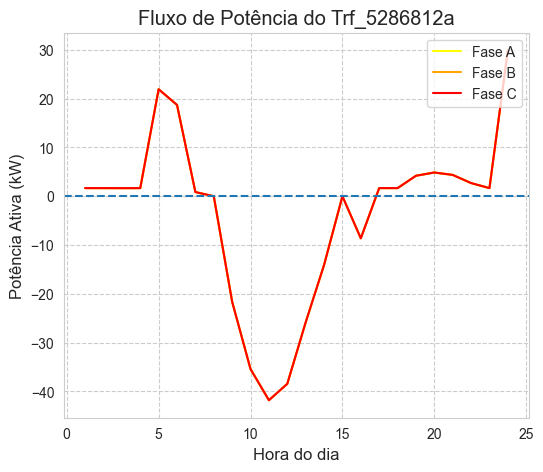

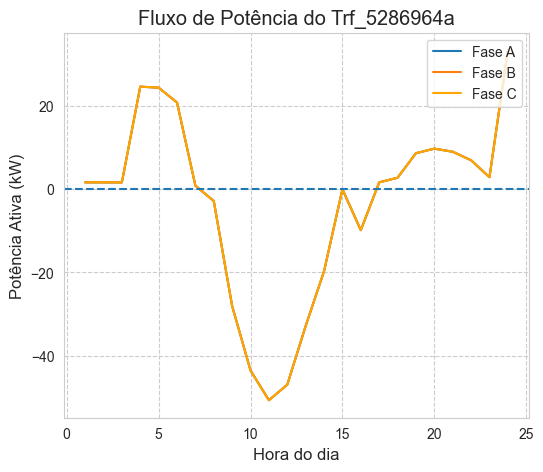

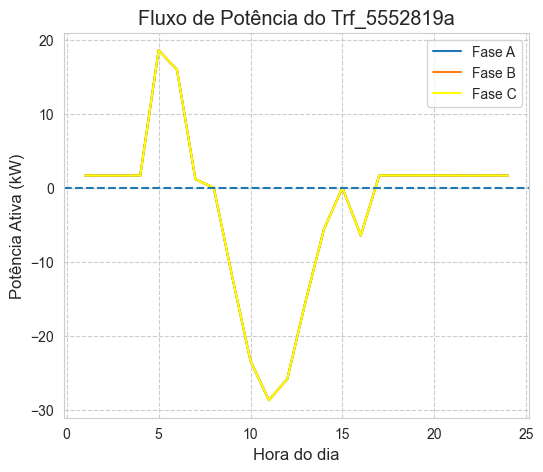

In [29]:
import matplotlib.pyplot as plt

df_trafo_1 = dss_tools.results.monitor("trf_5286812a")

df_trafo_2 = dss_tools.results.monitor("trf_5286964a")

df_trafo_3 = dss_tools.results.monitor("trf_5552819a")

#Trafo 1 = trf_5286812a
plt.plot(df_trafo_1["Hour"], df_trafo_1[" P1 (kW)"], label="Fase A", color="yellow")
plt.plot(df_trafo_1["Hour"], df_trafo_1[" P2 (kW)"], label="Fase B", color="orange")
plt.plot(df_trafo_1["Hour"], df_trafo_1[" P3 (kW)"], label="Fase C", color="red")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa (kW)")
plt.axhline(y=0, linestyle="--")
plt.legend()
plt.title("Fluxo de Potência do Trf_5286812a")
plt.show()

#Trafo 2 = trf_5286964a
plt.plot(df_trafo_2["Hour"], df_trafo_2[" P1 (kW)"], label="Fase A")
plt.plot(df_trafo_2["Hour"], df_trafo_2[" P2 (kW)"], label="Fase B")
plt.plot(df_trafo_2["Hour"], df_trafo_2[" P3 (kW)"], label="Fase C", color="orange")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa (kW)")
plt.axhline(y=0, linestyle="--")
plt.legend()
plt.title("Fluxo de Potência do Trf_5286964a")
plt.show()

#Trafo 2 = trf_5286964a
plt.plot(df_trafo_3["Hour"], df_trafo_3[" P1 (kW)"], label="Fase A")
plt.plot(df_trafo_3["Hour"], df_trafo_3[" P2 (kW)"], label="Fase B")
plt.plot(df_trafo_3["Hour"], df_trafo_3[" P3 (kW)"], label="Fase C", color="yellow")
plt.axhline(y=0, linestyle="--")
plt.xlabel("Hora do dia")
plt.ylabel("Potência Ativa (kW)")
plt.legend()
plt.title("Fluxo de Potência do Trf_5552819a")
plt.show()

Análise das Cargas nos Barramentos

In [4]:
loads_df = dss_tools.model.loads_df

loads_df["kw"] = pd.to_numeric(loads_df["kw"], errors="coerce")
loads_df = loads_df.sort_values(by='kw', ascending=False)

display(loads_df.head(15))

,name,phases,bus1,kv,kw,pf,model,yearly,daily,duty,...,zipv,%seriesrl,relweight,vlowpu,puxharm,xrharm,spectrum,basefreq,enabled,like
290,m1_trf_5286964a,3,82036275286964.1.2.3.4,0.38,69.143341,0.9042,2,,CURVA,,...,,50,1,0.5,0,6,defaultload,60,true,
147,m2_trf_5286964a,3,82036275286964.1.2.3.4,0.38,69.143341,0.9042,3,,CURVA,,...,,50,1,0.5,0,6,defaultload,60,true,
192,m1_trf_5286812a,3,82026915286812.1.2.3.4,0.38,62.255034,0.9062,2,,CURVA,,...,,50,1,0.5,0,6,defaultload,60,true,
49,m2_trf_5286812a,3,82026915286812.1.2.3.4,0.38,62.255034,0.9062,3,,CURVA,,...,,50,1,0.5,0,6,defaultload,60,true,
275,m1_trf_5552819a,3,82032765552819.1.2.3.4,0.38,51.943260,0.9099,2,,CURVA,,...,,50,1,0.5,0,6,defaultload,60,true,
132,m2_trf_5552819a,3,82032765552819.1.2.3.4,0.38,51.943260,0.9099,3,,CURVA,,...,,50,1,0.5,0,6,defaultload,60,true,
201,m1_trf_5286821a,3,82025745286821.1.2.3.4,0.38,50.507524,0.9059,2,,CURVA,,...,,50,1,0.5,0,6,defaultload,60,true,
58,m2_trf_5286821a,3,82025745286821.1.2.3.4,0.38,50.507524,0.9059,3,,CURVA,,...,,50,1,0.5,0,6,defaultload,60,true,
245,m1_trf_5286934a,3,82049885286934.1.2.3.4,0.38,50.292404,0.9058,2,,CURVA,,...,,50,1,0.5,0,6,defaultload,60,true,
102,m2_trf_5286934a,3,82049885286934.1.2.3.4,0.38,50.292404,0.9058,3,,CURVA,,...,,50,1,0.5,0,6,defaultload,60,true,


In [6]:
buses = loads_df["bus1"].unique().tolist()
print(len(buses))

147


Mapa Estático

In [7]:
dss_tools.interactive_view.circuit_plot("active power", show=True)